In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from itertools import combinations, product
from scipy.spatial import cKDTree
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

In [10]:
wt = './data/'
filename = 'nlin.tab'
apo_wt = wt + 'apo/' + filename
epi_wt = wt + 'apo/' + filename
cs_assignments = './data/HN-HMQC.50uM.Apo.WT.list'
tauList = np.array([float(i) for i in '106.0 106.5 107.0 107.5 108.0 108.5 109.0 109.5 110.0 110.5 111.0 111.5 112.0 112.5 113.0 113.5 114.0 114.5 115.0 115.5 116.0 116.5 117.0 117.5 118.0 118.5 119.0 119.5 120.0 120.5 121.0 121.5 122.0 122.5 123.0 123.5 124.0 124.5 125.0 125.5 126.0 126.5 127.0 127.5 128.0'.split()])

In [11]:
def read_assignments(filename, skiplines=2):
    
    contents = None
    with open(filename) as f:
        contents = [i.split() for i in f.readlines()[skiplines:]]
    H_shift, N_shift, Assignment = [], [], []
    for line in contents:
        Assignment.append(line[0][:-3])
        N_shift.append(line[1])
        H_shift.append(line[2])
    H_shift = np.array(H_shift, dtype=float)
    N_shift = np.array(N_shift, dtype=float)
    Assignment = np.array(Assignment, dtype='S6')
    out_dtype = np.dtype([('Assignment','S6'), ('H', 'f8'), ('N','f8')])
    out_array = np.zeros(len(H_shift), dtype=out_dtype)
    out_array['Assignment'] = Assignment
    out_array['H'] = H_shift
    out_array['N'] = N_shift
    return out_array

def read_cest(filename, skiplines=18):
    
    contents = None
    with open(filename) as f:
        contents = [i.split() for i in f.readlines()[skiplines:]]
    H_shift, N_shift, Z = [],[],[]
    for line in contents:
        H_shift.append(line[5])
        N_shift.append(line[6])
        Z.append(line[26:])
    H_shift = np.array(H_shift, dtype=float)
    N_shift = np.array(N_shift, dtype=float)
    Z = np.array(Z, dtype=float)
    out_dtype = np.dtype([('H','f8'),('N','f8'),('Z','f8', (Z.shape[1],))])
    out_array = np.zeros(len(H_shift), dtype=out_dtype)
    out_array['H'] = H_shift
    out_array['N'] = N_shift
    out_array['Z'] = Z
    return out_array

In [12]:
def robust_translation(points_a, points_b, threshold=1.0, max_iters=10):
    """
    Estimates translation between two point sets with extra points/outliers.
    """
    current_translation = np.array([0.0, 0.0])
    
    for _ in range(max_iters):
        # Shift points_a by current estimate
        shifted_a = points_a + current_translation
        
        # Build KD-Tree for efficient nearest neighbor search
        tree_b = cKDTree(points_b)
        
        # Find nearest neighbors and distances
        distances, indices = tree_b.query(shifted_a, k=1)
        
        # Select INLIERS: points closer than the threshold
        inlier_mask = distances < threshold
        inliers_a = shifted_a[inlier_mask]
        inliers_b = points_b[indices[inlier_mask]]
        
        if len(inliers_a) < 3:
            break # Not enough points to estimate
            
        # Recalculate translation based ONLY on inliers
        centroid_a = np.mean(inliers_a, axis=0)
        centroid_b = np.mean(inliers_b, axis=0)
        
        new_translation = centroid_b - (centroid_a - current_translation)
        
        # Check convergence
        if np.linalg.norm(new_translation - current_translation) < 1e-4:
            break
            
        current_translation = new_translation

    return current_translation
 

In [13]:
def strict_1_to_1_matching(points_a, points_b, translation_vector, threshold=1.0):
    """
    Enforces a strict 1-to-1 mapping between two point sets.
    """
    # 1. Apply translation to Set A
    shifted_a = points_a + translation_vector
    
    # 2. Compute the full cost matrix (Euclidean distances)
    # Shape: (len(points_a), len(points_b))
    cost_matrix = cdist(shifted_a, points_b, metric='euclidean')
    
    # 3. Solve the Linear Assignment Problem (Hungarian Algorithm)
    # This finds the unique pairing that minimizes the TOTAL sum of distances
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # 4. Filter matches based on the threshold
    # linear_sum_assignment matches EVERY point, so we must reject bad matches manually
    distances = cost_matrix[row_ind, col_ind]
    valid_mask = distances < threshold
    
    # 5. Return only the valid 1-to-1 indices
    final_indices_a = row_ind[valid_mask]
    final_indices_b = col_ind[valid_mask]
    final_distances = distances[valid_mask]
    
    return final_indices_a, final_indices_b, final_distances

In [14]:
assignments = read_assignments(cs_assignments)
cest = read_cest(apo_wt)
cest_epi = read_cest(epi_wt)
comp, arr = np.array(assignments[['H','N']].tolist()), np.array(cest[['H','N']].tolist())
shift = arr.mean(0)-comp.mean(0)
translate_by = robust_translation(comp, arr, threshold=0.1, max_iters=10000)

In [15]:
tree_comp = cKDTree(comp)

In [16]:
threshold = 0.10

distances, indices_b = tree_comp.query(np.array(cest[['H','N']].tolist()) + translate_by, k=1)
valid_match_mask = distances < threshold
    
# 5. Extract indices
indices_a = np.where(valid_match_mask)[0]
matched_indices_b = indices_b[valid_match_mask]
print(matched_indices_b, len(matched_indices_b))

[44 95 79 74 77 80 76 67 49 40 60 87 60 61 81 81 71 65 70 36 32 25 15 21
  1  8 78 76 77 73 33 88 79 76] 34


In [17]:
assignments['Assignment'][0].tolist()

b'G349'

In [18]:
idx_arr, idx_comp, dists = strict_1_to_1_matching(arr-shift, comp, shift, threshold=0.2)

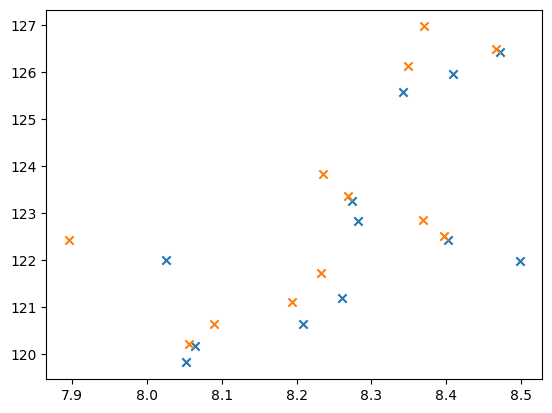

In [19]:
plt.scatter(*comp[idx_comp].T, marker='x')
plt.scatter(*(arr-shift)[idx_arr].T, marker='x')

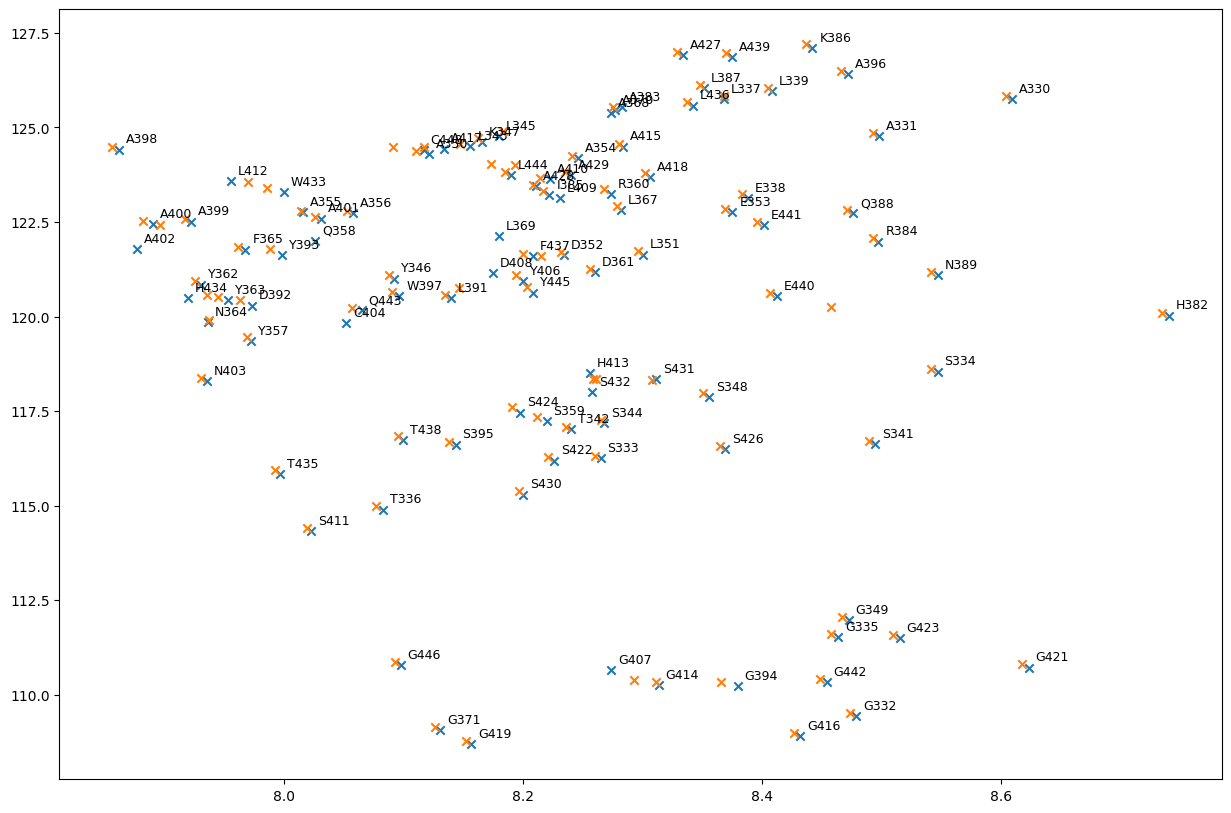

In [20]:
fig, ax = plt.subplots(1, figsize=(15,10))
ax.scatter(*comp.T, marker='x')
ax.scatter(*(arr-shift[None,:]).T, marker='x')
for i, txt in enumerate(zip(assignments['Assignment'])):
    ax.annotate(f"{txt[0].decode('UTF-8')}", (comp[i,0], comp[i,1]), xytext=(5, 5), 
                textcoords='offset points', fontsize=9)

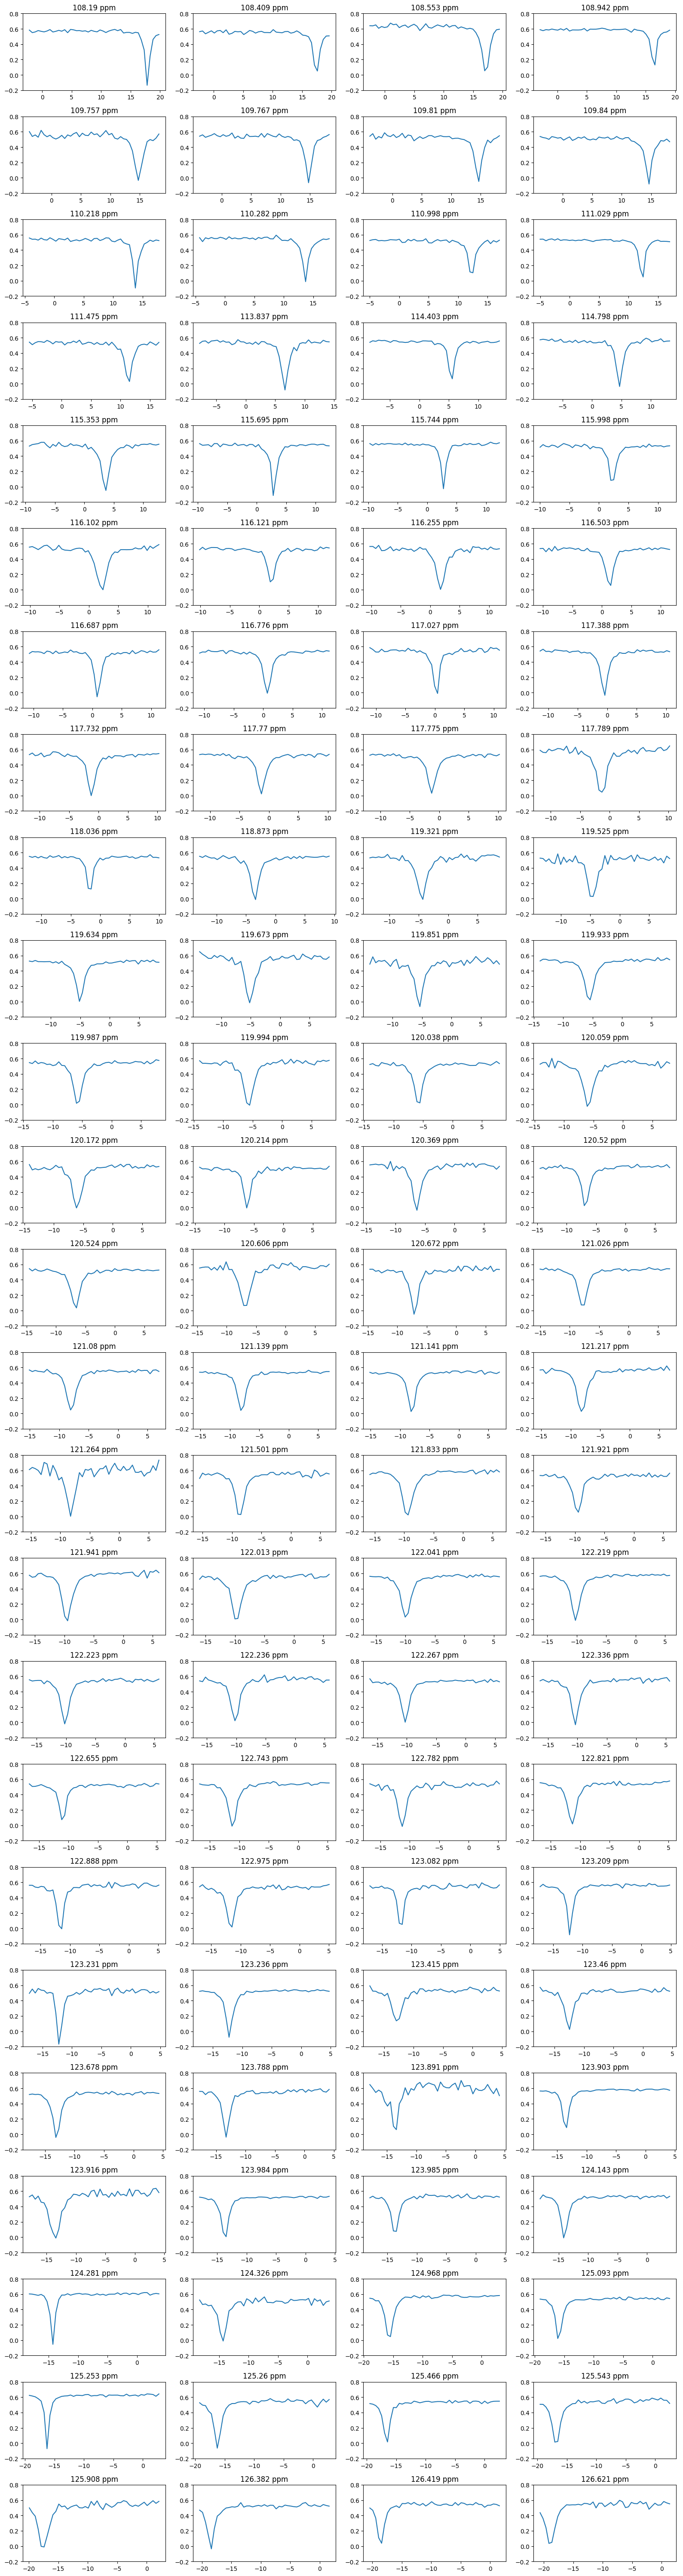

In [23]:
fig, ax = plt.subplots(int(np.ceil(cest['H'].shape[0]/4)), 4, figsize=(16,60))
axes = ax.flatten()
idx_order = np.argsort(cest['N'])
for i, entry in enumerate(cest[idx_order]):
    axes[i].plot(tauList-entry['N'], entry['Z'])
    axes[i].set_title(f'{entry['N']} ppm')
    axes[i].set_ylim(-0.2,0.8)
fig.tight_layout()
fig.savefig('./cest-apo.svg')

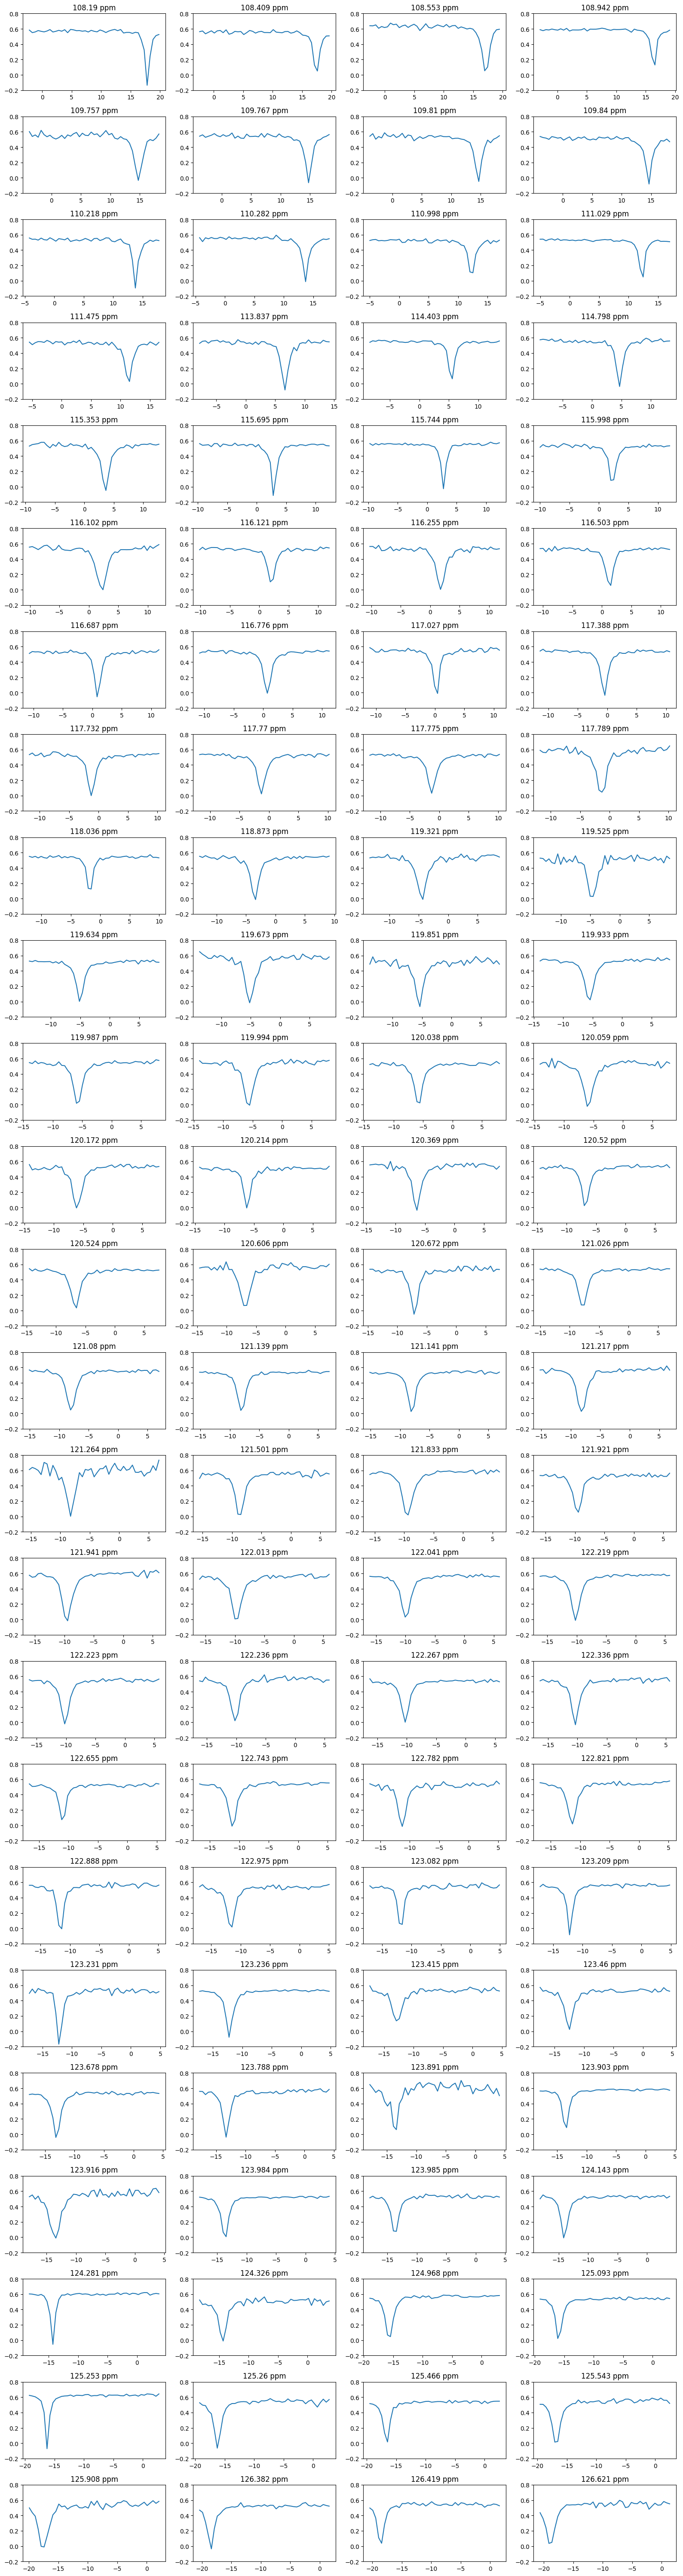

In [24]:
fig, ax = plt.subplots(int(np.ceil(cest_epi['H'].shape[0]/4)), 4, figsize=(16,60))
axes = ax.flatten()
idx_order = np.argsort(cest_epi['N'])
for i, entry in enumerate(cest_epi[idx_order]):
    axes[i].plot(tauList-entry['N'], entry['Z'])
    axes[i].set_title(f'{entry['N']} ppm')
    axes[i].set_ylim(-0.2,0.8)
fig.tight_layout()
fig.savefig('./cest_epi-epi.svg')